Old k: 87278846.0
effective k adjustment factor: 110844134.42


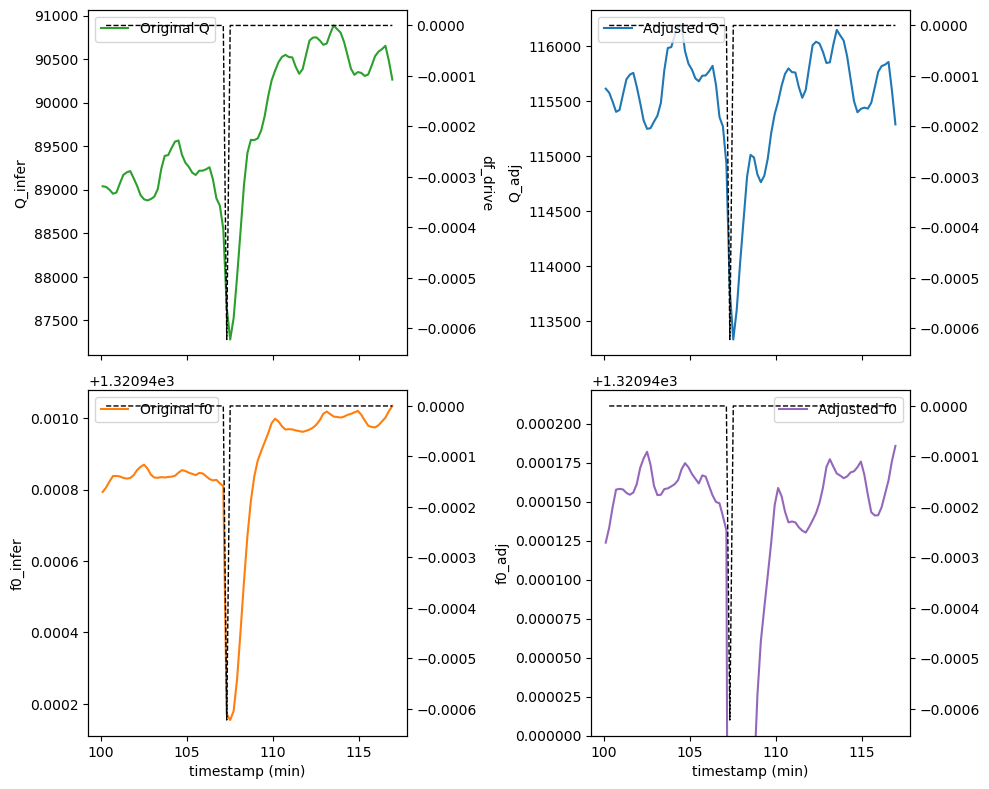

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# path = r'D:/Data/Fall25-Summer26/TO pll tracking/'
path = '/home/rakin/rnb76-rclone/Parpia group/D-Data-copy/Fall25-Summer26/TO pll tracking/'
datafile = 'DATA_2025-11-02_1.csv'

data = pd.read_csv(path + datafile, skiprows=15)

def calculate_Q_infer(X: np.ndarray, Y: np.ndarray, k: float) -> np.ndarray:
    return k * (X**2 + Y**2) / X


def calculate_f0_infer(X: np.ndarray, Y: np.ndarray, f_drive: float, k: float) -> np.ndarray:
    Q = calculate_Q_infer(X, Y, k)
    return f_drive * (1 + Y / (X * 2 * Q))

def rotate_XY(X: np.ndarray, Y: np.ndarray, angle_deg: float) -> tuple[np.ndarray, np.ndarray]:
    angle_rad = np.deg2rad(angle_deg)
    X_rot = X * np.cos(angle_rad) - Y * np.sin(angle_rad)
    Y_rot = X * np.sin(angle_rad) + Y * np.cos(angle_rad)
    return X_rot, Y_rot

data['timestamp'] -= data.timestamp.min()
data['timestamp'] /= 60
data = data.loc[data.timestamp > 100]

rot_angle = -8  # degrees
k_adj_factor = 1.27
print('Old k:', data['k'].iloc[0])
print('effective k adjustment factor:', k_adj_factor * data['k'].iloc[0])
k_adj = data['k'] * k_adj_factor
X_rot, Y_rot = rotate_XY(data['X'].to_numpy(), data['Y'].to_numpy(), angle_deg=rot_angle)

Q_adj = calculate_Q_infer(X_rot, Y_rot, k_adj)
f0_adj = calculate_f0_infer(X_rot, Y_rot, data['f_drive'], k_adj)





fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
(ax_tl, ax_tr), (ax_bl, ax_br) = axes

# Top-left: original Q
ax_tl.plot(data['timestamp'], data['Q_infer'], label='Original Q', color='tab:green')
ax_tl.set_ylabel('Q_infer')
ax_tl.legend(loc='upper left')
ax_tl_twin = ax_tl.twinx()
ax_tl_twin.plot(data['timestamp'], data['f_drive'].diff(), 'k--', lw=1)
ax_tl_twin.set_ylabel('df_drive', rotation=270, labelpad=12)

# Top-right: adjusted Q
ax_tr.plot(data['timestamp'], Q_adj, label='Adjusted Q', color='tab:blue')
ax_tr.set_ylabel('Q_adj')
ax_tr.legend(loc='upper left')
ax_tr_twin = ax_tr.twinx()
ax_tr_twin.plot(data['timestamp'], data['f_drive'].diff(), 'k--', lw=1)

# Bottom-left: original f0
ax_bl.plot(data['timestamp'], data['f0_infer'], label='Original f0', color='tab:orange')
ax_bl.set_ylabel('f0_infer')
ax_bl.legend(loc='upper left')
ax_bl_twin = ax_bl.twinx()
ax_bl_twin.plot(data['timestamp'], data['f_drive'].diff(), 'k--', lw=1)

# Bottom-right: adjusted f0
ax_br.plot(data['timestamp'], f0_adj, label='Adjusted f0', color='tab:purple')
ax_br.set_ylabel('f0_adj')
ax_br.legend()
ax_br_twin = ax_br.twinx()
ax_br_twin.plot(data['timestamp'], data['f_drive'].diff(), 'k--', lw=1)
ax_br.set_ylim(1.32094e3 - 0)
# common x label and layout
for ax in (ax_bl, ax_br):
    ax.set_xlabel('timestamp (min)')

fig.tight_layout()

